In [11]:
# =============================================================================
# HW08-09.ipynb
# PyTorch MLP: регуляризация и оптимизация обучения
# Датасет: EMNIST(split="balanced")
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 1: Импорты, seed, устройство
# ─────────────────────────────────────────────────────────────────────────────

import os
import json
import csv
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import EMNIST

# ── Воспроизводимость ──────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ── Устройство ─────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")
print(f"PyTorch:    {torch.__version__}")
print(f"Torchvision:{torchvision.__version__}")

# ── Директории артефактов ──────────────────────────────────────────────────
ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR   = ARTIFACTS_DIR / "figures"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nАртефакты → {ARTIFACTS_DIR.resolve()}")

Устройство: cpu
PyTorch:    2.10.0+cpu
Torchvision:0.25.0+cpu

Артефакты → C:\aie_group_local\aie-group\homeworks\HW08-09\artifacts


Train:  90240  |  Val:  22560  |  Test:  18800
Классов: 47

Батч x: torch.Size([128, 1, 28, 28])  dtype=torch.float32  min=-0.523  max=2.491
Батч y: torch.Size([128])  dtype=torch.int64  classes=45 in batch


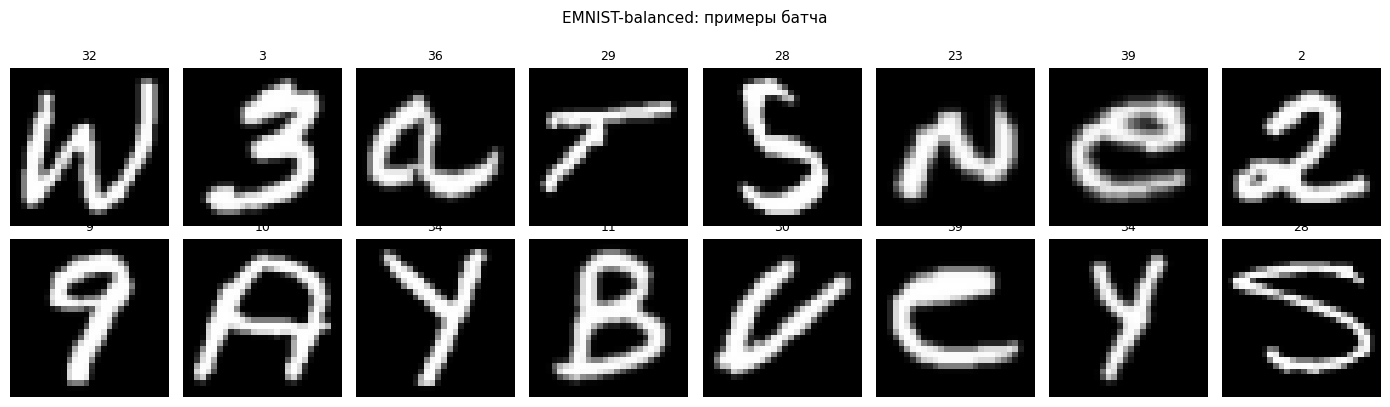

✔ sample_batch.png сохранён


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 2: Данные и DataLoader
# ─────────────────────────────────────────────────────────────────────────────

# EMNIST balanced: 47 классов (цифры 0-9 + заглавные/строчные буквы без
# омонимов), изображения 28×28, оттенки серого.
# Особенность torchvision: EMNIST возвращает изображения транспонированными
# относительно стандартной ориентации MNIST — добавляем lambda-трансформ.

DATASET   = "EMNIST"
NUM_CLASSES = 47
IMG_SIZE  = 28 * 28   # после Flatten
VAL_FRAC  = 0.20
BATCH_SIZE = 128
DATA_ROOT  = "./data"

transform = transforms.Compose([
    transforms.ToTensor(),
    # Исправляем транспонирование EMNIST
    transforms.Lambda(lambda x: x.permute(0, 2, 1)),  # (C,W,H) → (C,H,W)
    transforms.Normalize((0.1736,), (0.3317,)),        # статистики balanced
])

# ── Загрузка ───────────────────────────────────────────────────────────────
full_train = EMNIST(root=DATA_ROOT, split="balanced",
                    train=True,  download=True, transform=transform)
test_ds    = EMNIST(root=DATA_ROOT, split="balanced",
                    train=False, download=True, transform=transform)

# ── Train / Val split (80/20, фиксированный seed) ─────────────────────────
n_train = len(full_train)
n_val   = int(n_train * VAL_FRAC)
n_tr    = n_train - n_val

gen = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(full_train, [n_tr, n_val], generator=gen)

print(f"Train: {len(train_ds):>6}  |  Val: {len(val_ds):>6}  |  Test: {len(test_ds):>6}")
print(f"Классов: {NUM_CLASSES}")

# ── DataLoaders ────────────────────────────────────────────────────────────
def make_loader(ds, shuffle: bool) -> DataLoader:
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=0, pin_memory=(DEVICE.type == "cuda"))

train_loader = make_loader(train_ds, shuffle=True)
val_loader   = make_loader(val_ds,   shuffle=False)
test_loader  = make_loader(test_ds,  shuffle=False)

# ── Sanity-check ───────────────────────────────────────────────────────────
xb, yb = next(iter(train_loader))
print(f"\nБатч x: {xb.shape}  dtype={xb.dtype}  "
      f"min={xb.min():.3f}  max={xb.max():.3f}")
print(f"Батч y: {yb.shape}  dtype={yb.dtype}  "
      f"classes={yb.unique().numel()} in batch")

# ── Визуализация нескольких примеров ──────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = xb[i, 0].numpy()
    ax.imshow(img, cmap="gray")
    ax.set_title(str(yb[i].item()), fontsize=9)
    ax.axis("off")
plt.suptitle("EMNIST-balanced: примеры батча", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sample_batch.png", dpi=90, bbox_inches="tight")
plt.show()
print("✔ sample_batch.png сохранён")


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 3: MLP-архитектуры
# ─────────────────────────────────────────────────────────────────────────────

class MLP(nn.Module):
    """
    Универсальный MLP для EMNIST (28×28 → NUM_CLASSES).

    Параметры
    ----------
    hidden_sizes : list[int]   — размеры скрытых слоёв
    dropout_p    : float       — вероятность Dropout (0 = выключен)
    use_batchnorm: bool        — вставить BatchNorm после каждого Linear
    activation   : str         — 'relu' | 'gelu'
    """

    def __init__(
        self,
        hidden_sizes: list[int] = [512, 256, 128],
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
        activation: str = "relu",
        num_classes: int = NUM_CLASSES,
        input_dim: int = IMG_SIZE,
    ):
        super().__init__()

        act_fn = {"relu": nn.ReLU, "gelu": nn.GELU}[activation]

        layers: list[nn.Module] = [nn.Flatten()]

        in_features = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_fn())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            in_features = h

        layers.append(nn.Linear(in_features, num_classes))
        self.net = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

    def __repr__(self):
        total = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return (
            super().__repr__()
            + f"\n  → Параметров: {total:,}"
        )


# ── Быстрая проверка формы ────────────────────────────────────────────────
_dummy = MLP()
with torch.no_grad():
    out = _dummy(xb)
print(f"Выход MLP: {out.shape}")   # ожидаем [128, 47]
print(_dummy)

Выход MLP: torch.Size([128, 47])
MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=47, bias=True)
  )
)
  → Параметров: 572,207


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 4: Функции train / evaluate + EarlyStopping
# ─────────────────────────────────────────────────────────────────────────────

# ── Функции обучения ───────────────────────────────────────────────────────

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
) -> tuple[float, float]:
    """Один проход по train. Возвращает (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        correct    += (logits.argmax(1) == yb).sum().item()
        total      += xb.size(0)

    return total_loss / total, correct / total


def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float]:
    """Оценка на val/test. Возвращает (avg_loss, accuracy)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss   = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            correct    += (logits.argmax(1) == yb).sum().item()
            total      += xb.size(0)

    return total_loss / total, correct / total


# ── EarlyStopping ──────────────────────────────────────────────────────────

class EarlyStopping:
    """
    Останавливает обучение, если val_loss не улучшается patience эпох подряд.
    Сохраняет best state_dict в памяти.
    """

    def __init__(self, patience: int = 5, min_delta: float = 1e-4,
                 save_path: Path | None = None):
        self.patience   = patience
        self.min_delta  = min_delta
        self.save_path  = save_path
        self.best_loss  = float("inf")
        self.counter    = 0
        self.best_state = None
        self.stopped_epoch = 0

    def __call__(self, val_loss: float, model: nn.Module, epoch: int) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.cpu().clone()
                               for k, v in model.state_dict().items()}
            if self.save_path:
                torch.save(self.best_state, self.save_path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped_epoch = epoch
                return True   # стоп
        return False

    def restore(self, model: nn.Module):
        """Восстановить веса лучшей эпохи."""
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


# ── Обёртка полного цикла обучения ────────────────────────────────────────

def run_training(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
    max_epochs: int = 20,
    early_stopping: EarlyStopping | None = None,
    verbose: bool = True,
    experiment_id: str = "",
) -> dict:
    """
    Полный цикл обучения.
    Возвращает словарь с историей метрик.
    """
    model.to(device)
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc":  [], "val_acc":  [],
    }
    best_val_acc  = 0.0
    best_val_loss = float("inf")

    for epoch in range(1, max_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc = evaluate(
            model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc  = vl_acc
            best_val_loss = vl_loss

        if verbose:
            tag = f"[{experiment_id}]" if experiment_id else ""
            print(f"{tag} Epoch {epoch:>2}/{max_epochs} | "
                  f"tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f} | "
                  f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}")

        if early_stopping is not None:
            if early_stopping(vl_loss, model, epoch):
                print(f"  ⛔ EarlyStopping на эпохе {epoch} "
                      f"(patience={early_stopping.patience})")
                break

    history["best_val_acc"]  = best_val_acc
    history["best_val_loss"] = best_val_loss
    history["epochs_trained"] = len(history["train_loss"])
    return history


print("✔ Функции train_one_epoch / evaluate / EarlyStopping определены")

✔ Функции train_one_epoch / evaluate / EarlyStopping определены


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 5: Хранилище результатов
# ─────────────────────────────────────────────────────────────────────────────

RUNS: list[dict] = []   # накапливаем строки для runs.csv

CRITERION = nn.CrossEntropyLoss()

MAX_EPOCHS = 5         # единый лимит для экспериментов A
EPOCHS_OPT  = 5        # для экспериментов B (O1-O3)

def record_run(experiment_id, history, model_summary,
               optimizer_name, lr, momentum=None,
               weight_decay=0.0):
    RUNS.append({
        "experiment_id":   experiment_id,
        "dataset":         DATASET,
        "seed":            SEED,
        "model_summary":   model_summary,
        "optimizer":       optimizer_name,
        "lr":              lr,
        "momentum":        momentum if momentum is not None else "",
        "weight_decay":    weight_decay,
        "epochs_trained":  history["epochs_trained"],
        "best_val_accuracy": round(history["best_val_acc"],  4),
        "best_val_loss":     round(history["best_val_loss"], 4),
    })
    print(f"  ✔ [{experiment_id}] val_acc={history['best_val_acc']:.4f}  "
          f"epochs={history['epochs_trained']}")


def save_runs_csv():
    path = ARTIFACTS_DIR / "runs.csv"
    if not RUNS:
        return
    fieldnames = list(RUNS[0].keys())
    with open(path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(RUNS)
    print(f"✔ runs.csv сохранён → {path}")

print("✔ Хранилище результатов готово")

✔ Хранилище результатов готово


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 6: E1 — Base MLP (без Dropout, без BatchNorm)
# ─────────────────────────────────────────────────────────────────────────────

set_seed(SEED)

HIDDEN = [512, 256, 128]   # единая архитектура для A и B
LR_BASE = 3e-4

model_e1 = MLP(hidden_sizes=HIDDEN, dropout_p=0.0, use_batchnorm=False)
opt_e1   = optim.Adam(model_e1.parameters(), lr=LR_BASE)

print("=" * 60)
print("E1: Base MLP — без регуляризации")
print("=" * 60)

hist_e1 = run_training(
    model_e1, train_loader, val_loader,
    CRITERION, opt_e1, DEVICE,
    max_epochs=MAX_EPOCHS,
    experiment_id="E1",
)

record_run(
    "E1", hist_e1,
    model_summary="[512,256,128] ReLU | no Dropout | no BN",
    optimizer_name="Adam", lr=LR_BASE,
)

E1: Base MLP — без регуляризации
[E1] Epoch  1/5 | tr_loss=1.1962  tr_acc=0.6582 | val_loss=0.7919  val_acc=0.7543
[E1] Epoch  2/5 | tr_loss=0.6527  tr_acc=0.7943 | val_loss=0.6380  val_acc=0.8007
[E1] Epoch  3/5 | tr_loss=0.5213  tr_acc=0.8296 | val_loss=0.5726  val_acc=0.8131
[E1] Epoch  4/5 | tr_loss=0.4466  tr_acc=0.8489 | val_loss=0.5396  val_acc=0.8255
[E1] Epoch  5/5 | tr_loss=0.3934  tr_acc=0.8655 | val_loss=0.5192  val_acc=0.8282
  ✔ [E1] val_acc=0.8282  epochs=5


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 7: E2 — MLP + Dropout
# ─────────────────────────────────────────────────────────────────────────────

set_seed(SEED)

DROPOUT_P = 0.3

model_e2 = MLP(hidden_sizes=HIDDEN, dropout_p=DROPOUT_P, use_batchnorm=False)
opt_e2   = optim.Adam(model_e2.parameters(), lr=LR_BASE)

print("=" * 60)
print(f"E2: MLP + Dropout(p={DROPOUT_P})")
print("=" * 60)

hist_e2 = run_training(
    model_e2, train_loader, val_loader,
    CRITERION, opt_e2, DEVICE,
    max_epochs=MAX_EPOCHS,
    experiment_id="E2",
)

record_run(
    "E2", hist_e2,
    model_summary=f"[512,256,128] ReLU | Dropout(p={DROPOUT_P}) | no BN",
    optimizer_name="Adam", lr=LR_BASE,
)

E2: MLP + Dropout(p=0.3)
[E2] Epoch  1/5 | tr_loss=2.3267  tr_acc=0.3750 | val_loss=1.0610  val_acc=0.6965
[E2] Epoch  2/5 | tr_loss=1.2911  tr_acc=0.6193 | val_loss=0.7938  val_acc=0.7603
[E2] Epoch  3/5 | tr_loss=1.0348  tr_acc=0.6846 | val_loss=0.6767  val_acc=0.7882
[E2] Epoch  4/5 | tr_loss=0.8898  tr_acc=0.7234 | val_loss=0.6199  val_acc=0.8013
[E2] Epoch  5/5 | tr_loss=0.7992  tr_acc=0.7471 | val_loss=0.5772  val_acc=0.8132
  ✔ [E2] val_acc=0.8132  epochs=5


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 8: E3 — MLP + BatchNorm
# ─────────────────────────────────────────────────────────────────────────────

set_seed(SEED)

model_e3 = MLP(hidden_sizes=HIDDEN, dropout_p=0.0, use_batchnorm=True)
opt_e3   = optim.Adam(model_e3.parameters(), lr=LR_BASE)

print("=" * 60)
print("E3: MLP + BatchNorm")
print("=" * 60)

hist_e3 = run_training(
    model_e3, train_loader, val_loader,
    CRITERION, opt_e3, DEVICE,
    max_epochs=MAX_EPOCHS,
    experiment_id="E3",
)

record_run(
    "E3", hist_e3,
    model_summary="[512,256,128] ReLU | no Dropout | BatchNorm",
    optimizer_name="Adam", lr=LR_BASE,
)

E3: MLP + BatchNorm
[E3] Epoch  1/5 | tr_loss=1.3419  tr_acc=0.6540 | val_loss=0.7815  val_acc=0.7733
[E3] Epoch  2/5 | tr_loss=0.6475  tr_acc=0.8033 | val_loss=0.5933  val_acc=0.8165
[E3] Epoch  3/5 | tr_loss=0.5008  tr_acc=0.8397 | val_loss=0.5292  val_acc=0.8298
[E3] Epoch  4/5 | tr_loss=0.4230  tr_acc=0.8601 | val_loss=0.5004  val_acc=0.8366
[E3] Epoch  5/5 | tr_loss=0.3696  tr_acc=0.8743 | val_loss=0.4926  val_acc=0.8379
  ✔ [E3] val_acc=0.8379  epochs=5


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 9: E4 — Лучший конфиг + EarlyStopping
# ─────────────────────────────────────────────────────────────────────────────

# Выбираем лучшего из E2 / E3 по val_accuracy
best_prev = max(
    [("E2", hist_e2["best_val_acc"], DROPOUT_P, False),
     ("E3", hist_e3["best_val_acc"], 0.0,       True)],
    key=lambda t: t[1]
)
best_name, best_acc, best_drop, best_bn = best_prev
print(f"Лучший предыдущий эксперимент: {best_name}  (val_acc={best_acc:.4f})")
print(f"  → Dropout p={best_drop}  BatchNorm={best_bn}")

set_seed(SEED)

BEST_MODEL_PATH = ARTIFACTS_DIR / "best_model.pt"
es = EarlyStopping(patience=5, min_delta=1e-4, save_path=BEST_MODEL_PATH)

model_e4 = MLP(hidden_sizes=HIDDEN,
               dropout_p=best_drop,
               use_batchnorm=best_bn)
opt_e4   = optim.Adam(model_e4.parameters(), lr=LR_BASE)

print("=" * 60)
print(f"E4: {best_name}-конфиг + EarlyStopping(patience=5)")
print("=" * 60)

hist_e4 = run_training(
    model_e4, train_loader, val_loader,
    CRITERION, opt_e4, DEVICE,
    max_epochs=MAX_EPOCHS,
    early_stopping=es,
    experiment_id="E4",
)

# Восстанавливаем лучшие веса (на случай, если последняя эпоха не лучшая)
es.restore(model_e4)

record_run(
    "E4", hist_e4,
    model_summary=(f"[512,256,128] ReLU | Dropout(p={best_drop}) | "
                   f"BN={best_bn} | EarlyStopping(patience=5)"),
    optimizer_name="Adam", lr=LR_BASE,
)

print(f"\n  EarlyStopping остановил на эпохе: {es.stopped_epoch or 'не сработал'}")
print(f"  best_model.pt сохранён → {BEST_MODEL_PATH}")

Лучший предыдущий эксперимент: E3  (val_acc=0.8379)
  → Dropout p=0.0  BatchNorm=True
E4: E3-конфиг + EarlyStopping(patience=5)
[E4] Epoch  1/5 | tr_loss=1.3419  tr_acc=0.6540 | val_loss=0.7815  val_acc=0.7733
[E4] Epoch  2/5 | tr_loss=0.6475  tr_acc=0.8033 | val_loss=0.5933  val_acc=0.8165
[E4] Epoch  3/5 | tr_loss=0.5008  tr_acc=0.8397 | val_loss=0.5292  val_acc=0.8298
[E4] Epoch  4/5 | tr_loss=0.4230  tr_acc=0.8601 | val_loss=0.5004  val_acc=0.8366
[E4] Epoch  5/5 | tr_loss=0.3696  tr_acc=0.8743 | val_loss=0.4926  val_acc=0.8379
  ✔ [E4] val_acc=0.8379  epochs=5

  EarlyStopping остановил на эпохе: не сработал
  best_model.pt сохранён → artifacts\best_model.pt


✔ График сохранён → artifacts\figures\curves_best.png


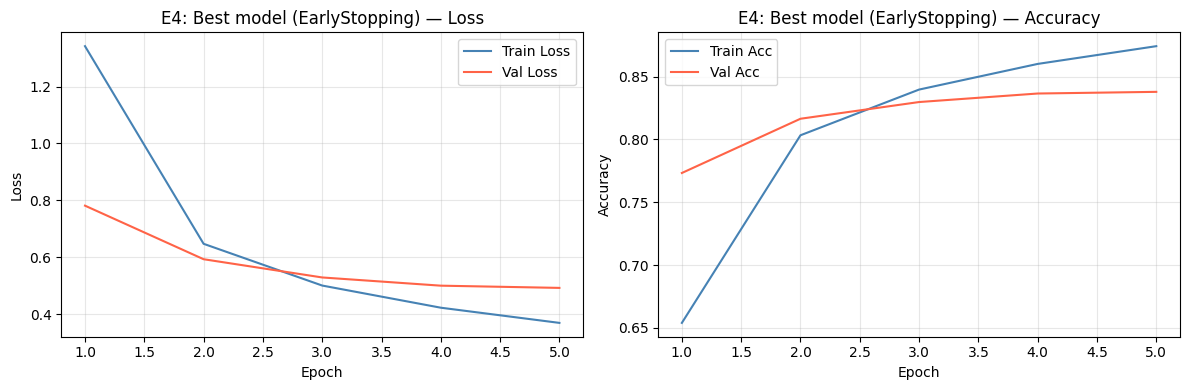

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 10: График curves_best.png (E4)
# ─────────────────────────────────────────────────────────────────────────────

def plot_history(history: dict, title: str, save_path: Path | None = None):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    ax1.plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
    ax1.plot(epochs, history["val_loss"],   label="Val Loss",   color="tomato")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} — Loss")
    ax1.legend(); ax1.grid(alpha=0.3)

    # Accuracy
    ax2.plot(epochs, history["train_acc"], label="Train Acc", color="steelblue")
    ax2.plot(epochs, history["val_acc"],   label="Val Acc",   color="tomato")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title} — Accuracy")
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
        print(f"✔ График сохранён → {save_path}")
    plt.show()


plot_history(hist_e4, "E4: Best model (EarlyStopping)",
             save_path=FIGURES_DIR / "curves_best.png")

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 11: Финальная оценка лучшей модели на TEST (один раз)
# ─────────────────────────────────────────────────────────────────────────────

test_loss, test_acc = evaluate(model_e4, test_loader, CRITERION, DEVICE)
print(f"\n{'='*50}")
print(f"  TEST ACCURACY (E4 — лучшая модель): {test_acc:.4f}")
print(f"  TEST LOSS:                          {test_loss:.4f}")
print(f"{'='*50}")



  TEST ACCURACY (E4 — лучшая модель): 0.8323
  TEST LOSS:                          0.5103


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 12: Сохранение best_config.json
# ─────────────────────────────────────────────────────────────────────────────

best_config = {
    "dataset":      "EMNIST",
    "emnist_split": "balanced",
    "seed":         SEED,
    "hidden_sizes": HIDDEN,
    "activation":   "relu",
    "dropout_p":    best_drop,
    "use_batchnorm": best_bn,
    "num_classes":  NUM_CLASSES,
    "input_dim":    IMG_SIZE,
    "optimizer":    "Adam",
    "lr":           LR_BASE,
    "weight_decay": 0.0,
    "batch_size":   BATCH_SIZE,
    "max_epochs":   MAX_EPOCHS,
    "early_stopping_patience": 5,
    "val_frac":     VAL_FRAC,
    "best_val_accuracy": round(hist_e4["best_val_acc"], 4),
    "test_accuracy":     round(test_acc, 4),
    "test_loss":         round(test_loss, 4),
    "experiment_id": "E4",
}

config_path = ARTIFACTS_DIR / "best_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(best_config, f, indent=2, ensure_ascii=False)

print(f"✔ best_config.json сохранён → {config_path}")
print(json.dumps(best_config, indent=2, ensure_ascii=False))


✔ best_config.json сохранён → artifacts\best_config.json
{
  "dataset": "EMNIST",
  "emnist_split": "balanced",
  "seed": 42,
  "hidden_sizes": [
    512,
    256,
    128
  ],
  "activation": "relu",
  "dropout_p": 0.0,
  "use_batchnorm": true,
  "num_classes": 47,
  "input_dim": 784,
  "optimizer": "Adam",
  "lr": 0.0003,
  "weight_decay": 0.0,
  "batch_size": 128,
  "max_epochs": 5,
  "early_stopping_patience": 5,
  "val_frac": 0.2,
  "best_val_accuracy": 0.8379,
  "test_accuracy": 0.8323,
  "test_loss": 0.5103,
  "experiment_id": "E4"
}


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 13: Часть B — O1: Adam, LR слишком большой (1e-1)
# ─────────────────────────────────────────────────────────────────────────────

set_seed(SEED)

LR_BIG = 1e-1
EPOCHS_DIAG = 8

model_o1 = MLP(hidden_sizes=HIDDEN,
               dropout_p=best_drop,
               use_batchnorm=best_bn)
opt_o1   = optim.Adam(model_o1.parameters(), lr=LR_BIG)

print("=" * 60)
print(f"O1: Adam, lr={LR_BIG}  ← слишком большой")
print("=" * 60)

hist_o1 = run_training(
    model_o1, train_loader, val_loader,
    CRITERION, opt_o1, DEVICE,
    max_epochs=EPOCHS_DIAG,
    experiment_id="O1",
)

record_run(
    "O1", hist_o1,
    model_summary=f"[512,256,128] ReLU | Dropout(p={best_drop}) | BN={best_bn}",
    optimizer_name="Adam", lr=LR_BIG,
)


O1: Adam, lr=0.1  ← слишком большой
[O1] Epoch  1/8 | tr_loss=1.0812  tr_acc=0.6716 | val_loss=0.8119  val_acc=0.7387
[O1] Epoch  2/8 | tr_loss=0.7302  tr_acc=0.7643 | val_loss=0.6819  val_acc=0.7876
[O1] Epoch  3/8 | tr_loss=0.6538  tr_acc=0.7858 | val_loss=0.6131  val_acc=0.8008
[O1] Epoch  4/8 | tr_loss=0.5994  tr_acc=0.8003 | val_loss=0.6283  val_acc=0.8068
[O1] Epoch  5/8 | tr_loss=0.5693  tr_acc=0.8098 | val_loss=0.5845  val_acc=0.8139
[O1] Epoch  6/8 | tr_loss=0.5439  tr_acc=0.8160 | val_loss=0.5548  val_acc=0.8285
[O1] Epoch  7/8 | tr_loss=0.5147  tr_acc=0.8248 | val_loss=0.5648  val_acc=0.8258
[O1] Epoch  8/8 | tr_loss=0.4966  tr_acc=0.8301 | val_loss=0.5623  val_acc=0.8220
  ✔ [O1] val_acc=0.8285  epochs=8


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 14: O2 — Adam, LR слишком маленький (1e-5)
# ─────────────────────────────────────────────────────────────────────────────

set_seed(SEED)

LR_SMALL = 1e-5

model_o2 = MLP(hidden_sizes=HIDDEN,
               dropout_p=best_drop,
               use_batchnorm=best_bn)
opt_o2   = optim.Adam(model_o2.parameters(), lr=LR_SMALL)

print("=" * 60)
print(f"O2: Adam, lr={LR_SMALL}  ← слишком маленький")
print("=" * 60)

hist_o2 = run_training(
    model_o2, train_loader, val_loader,
    CRITERION, opt_o2, DEVICE,
    max_epochs=EPOCHS_DIAG,
    experiment_id="O2",
)

record_run(
    "O2", hist_o2,
    model_summary=f"[512,256,128] ReLU | Dropout(p={best_drop}) | BN={best_bn}",
    optimizer_name="Adam", lr=LR_SMALL,
)


O2: Adam, lr=1e-05  ← слишком маленький
[O2] Epoch  1/8 | tr_loss=3.6574  tr_acc=0.1082 | val_loss=3.0807  val_acc=0.2292
[O2] Epoch  2/8 | tr_loss=2.7506  tr_acc=0.3301 | val_loss=2.4624  val_acc=0.4123
[O2] Epoch  3/8 | tr_loss=2.2815  tr_acc=0.4651 | val_loss=2.1080  val_acc=0.5078
[O2] Epoch  4/8 | tr_loss=1.9855  tr_acc=0.5363 | val_loss=1.8703  val_acc=0.5634
[O2] Epoch  5/8 | tr_loss=1.7750  tr_acc=0.5841 | val_loss=1.6935  val_acc=0.5997
[O2] Epoch  6/8 | tr_loss=1.6130  tr_acc=0.6203 | val_loss=1.5517  val_acc=0.6295
[O2] Epoch  7/8 | tr_loss=1.4837  tr_acc=0.6474 | val_loss=1.4392  val_acc=0.6525
[O2] Epoch  8/8 | tr_loss=1.3795  tr_acc=0.6671 | val_loss=1.3430  val_acc=0.6726
  ✔ [O2] val_acc=0.6726  epochs=8


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 15: O3 — SGD + momentum + weight decay
# ─────────────────────────────────────────────────────────────────────────────

set_seed(SEED)

LR_SGD      = 1e-2
MOMENTUM    = 0.9
WEIGHT_DECAY = 1e-4
EPOCHS_SGD  = 15

model_o3 = MLP(hidden_sizes=HIDDEN,
               dropout_p=best_drop,
               use_batchnorm=best_bn)
opt_o3   = optim.SGD(model_o3.parameters(),
                     lr=LR_SGD,
                     momentum=MOMENTUM,
                     weight_decay=WEIGHT_DECAY)

print("=" * 60)
print(f"O3: SGD(lr={LR_SGD}, momentum={MOMENTUM}, wd={WEIGHT_DECAY})")
print("=" * 60)

hist_o3 = run_training(
    model_o3, train_loader, val_loader,
    CRITERION, opt_o3, DEVICE,
    max_epochs=EPOCHS_SGD,
    experiment_id="O3",
)

record_run(
    "O3", hist_o3,
    model_summary=f"[512,256,128] ReLU | Dropout(p={best_drop}) | BN={best_bn}",
    optimizer_name="SGD",
    lr=LR_SGD,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
)


O3: SGD(lr=0.01, momentum=0.9, wd=0.0001)
[O3] Epoch  1/15 | tr_loss=1.1398  tr_acc=0.6850 | val_loss=0.6919  val_acc=0.7833
[O3] Epoch  2/15 | tr_loss=0.5871  tr_acc=0.8127 | val_loss=0.5629  val_acc=0.8181
[O3] Epoch  3/15 | tr_loss=0.4739  tr_acc=0.8436 | val_loss=0.5187  val_acc=0.8291
[O3] Epoch  4/15 | tr_loss=0.4085  tr_acc=0.8615 | val_loss=0.4968  val_acc=0.8363
[O3] Epoch  5/15 | tr_loss=0.3630  tr_acc=0.8730 | val_loss=0.4974  val_acc=0.8346
[O3] Epoch  6/15 | tr_loss=0.3279  tr_acc=0.8843 | val_loss=0.5014  val_acc=0.8317
[O3] Epoch  7/15 | tr_loss=0.2988  tr_acc=0.8932 | val_loss=0.4970  val_acc=0.8356
[O3] Epoch  8/15 | tr_loss=0.2747  tr_acc=0.9005 | val_loss=0.4960  val_acc=0.8400
[O3] Epoch  9/15 | tr_loss=0.2560  tr_acc=0.9061 | val_loss=0.4939  val_acc=0.8389
[O3] Epoch 10/15 | tr_loss=0.2369  tr_acc=0.9123 | val_loss=0.5011  val_acc=0.8377
[O3] Epoch 11/15 | tr_loss=0.2221  tr_acc=0.9165 | val_loss=0.5086  val_acc=0.8393
[O3] Epoch 12/15 | tr_loss=0.2057  tr_acc=0.9

✔ curves_lr_extremes.png сохранён → artifacts\figures\curves_lr_extremes.png


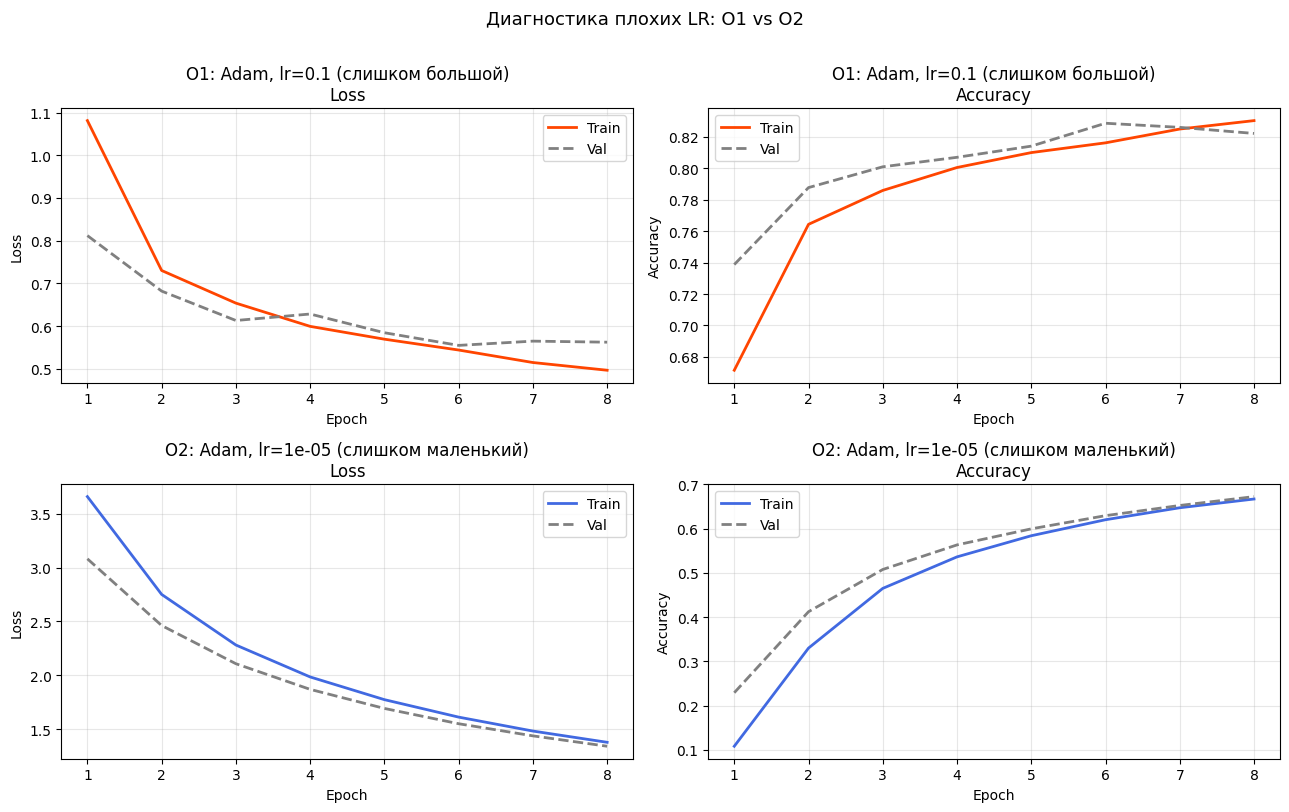

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 16: График curves_lr_extremes.png (O1 и O2)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

configs = [
    (hist_o1, f"O1: Adam, lr={LR_BIG} (слишком большой)", "orangered"),
    (hist_o2, f"O2: Adam, lr={LR_SMALL} (слишком маленький)", "royalblue"),
]

for row, (hist, label, color) in enumerate(configs):
    ep = range(1, len(hist["train_loss"]) + 1)
    # Loss
    ax = axes[row, 0]
    ax.plot(ep, hist["train_loss"], label="Train", color=color,   lw=2)
    ax.plot(ep, hist["val_loss"],   label="Val",   color="gray",  lw=2, ls="--")
    ax.set_title(f"{label}\nLoss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(alpha=0.3)
    # Accuracy
    ax = axes[row, 1]
    ax.plot(ep, hist["train_acc"], label="Train", color=color,  lw=2)
    ax.plot(ep, hist["val_acc"],   label="Val",   color="gray", lw=2, ls="--")
    ax.set_title(f"{label}\nAccuracy")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Диагностика плохих LR: O1 vs O2", fontsize=13, y=1.01)
plt.tight_layout()
lr_path = FIGURES_DIR / "curves_lr_extremes.png"
plt.savefig(lr_path, dpi=120, bbox_inches="tight")
print(f"✔ curves_lr_extremes.png сохранён → {lr_path}")
plt.show()


✔ curves_partA_summary.png сохранён → artifacts\figures\curves_partA_summary.png


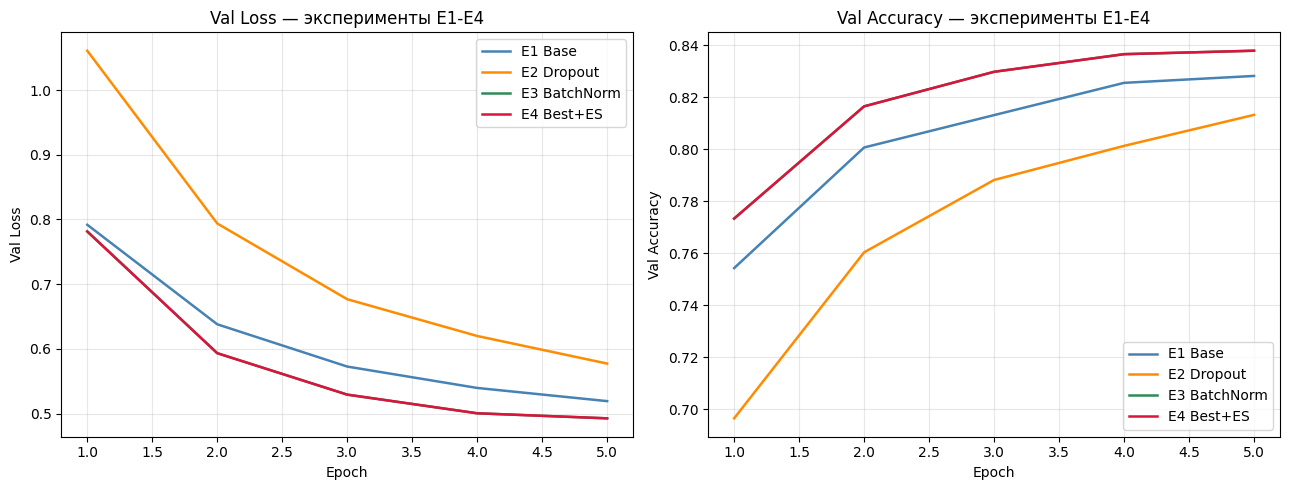

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 17: Сводный график всех экспериментов A (E1-E4)
# ─────────────────────────────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

exp_map = {
    "E1 Base":             (hist_e1, "steelblue",   "-"),
    "E2 Dropout":          (hist_e2, "darkorange",  "-"),
    "E3 BatchNorm":        (hist_e3, "seagreen",    "-"),
    f"E4 Best+ES":         (hist_e4, "crimson",     "-"),
}

for label, (hist, color, ls) in exp_map.items():
    ep = range(1, len(hist["train_loss"]) + 1)
    ax1.plot(ep, hist["val_loss"], label=label, color=color, ls=ls, lw=1.8)
    ax2.plot(ep, hist["val_acc"],  label=label, color=color, ls=ls, lw=1.8)

ax1.set_title("Val Loss — эксперименты E1-E4")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Val Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.set_title("Val Accuracy — эксперименты E1-E4")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val Accuracy")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
summary_path = FIGURES_DIR / "curves_partA_summary.png"
plt.savefig(summary_path, dpi=120, bbox_inches="tight")
print(f"✔ curves_partA_summary.png сохранён → {summary_path}")
plt.show()


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# ЯЧЕЙКА 18: Сохранение runs.csv + итоговая таблица
# ─────────────────────────────────────────────────────────────────────────────

save_runs_csv()

# Печать в ноутбуке
print("\n" + "=" * 80)
print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 80)
header = ["ID", "Optimizer", "LR", "Mom", "WD", "Epochs",
          "val_acc", "val_loss"]
print(f"{'ID':<6} {'Optimizer':<8} {'LR':>8} {'Mom':>6} {'WD':>7} "
      f"{'Epochs':>6} {'val_acc':>8} {'val_loss':>9}")
print("-" * 65)
for r in RUNS:
    print(f"{r['experiment_id']:<6} {r['optimizer']:<8} {r['lr']:>8} "
          f"{str(r['momentum']):>6} {r['weight_decay']:>7} "
          f"{r['epochs_trained']:>6} {r['best_val_accuracy']:>8.4f} "
          f"{r['best_val_loss']:>9.4f}")

print("=" * 80)
print(f"\nTest accuracy лучшей модели (E4): {test_acc:.4f}")
print(f"Test loss     лучшей модели (E4): {test_loss:.4f}")


✔ runs.csv сохранён → artifacts\runs.csv

ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
ID     Optimizer       LR    Mom      WD Epochs  val_acc  val_loss
-----------------------------------------------------------------
E1     Adam       0.0003            0.0      5   0.8282    0.5192
E2     Adam       0.0003            0.0      5   0.8132    0.5772
E3     Adam       0.0003            0.0      5   0.8379    0.4926
E4     Adam       0.0003            0.0      5   0.8379    0.4926
O1     Adam          0.1            0.0      8   0.8285    0.5548
O2     Adam        1e-05            0.0      8   0.6726    1.3430
O3     SGD          0.01    0.9  0.0001     15   0.8402    0.5188

Test accuracy лучшей модели (E4): 0.8323
Test loss     лучшей модели (E4): 0.5103
